In [14]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pickle
import matplotlib.pyplot as plt

In [15]:
df = pd.read_csv('cleaned_deceptive-opinion.csv')

In [16]:
df.isnull().sum()

deceptive    0
hotel        0
polarity     0
source       0
text         0
dtype: int64

In [17]:
np.random.seed(42)

In [18]:
df['target'] = df['deceptive'].map({'deceptive': 1, 'truthful': 0})
X = df['text']
y = df['target']

In [19]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
vectorizer = TfidfVectorizer(max_features=5000)
x_train_vectors = vectorizer.fit_transform(x_train)
x_test_vectors = vectorizer.transform(x_test)

In [21]:
model = MLPClassifier(hidden_layer_sizes=(16,), activation='relu', solver='adam', max_iter=50, random_state=42)
model.fit(x_train_vectors, y_train)

c:\Users\HFCS\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(16,), max_iter=50, random_state=42)

In [22]:
y_pred = model.predict(x_test_vectors)
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc:.4f}')
print(classification_report(y_test, y_pred, target_names=['truthful', 'deceptive']))

Accuracy: 0.8781
              precision    recall  f1-score   support

    truthful       0.90      0.87      0.88       168
   deceptive       0.86      0.89      0.87       152

    accuracy                           0.88       320
   macro avg       0.88      0.88      0.88       320
weighted avg       0.88      0.88      0.88       320



In [23]:
with open('nn_model.pkl', 'wb') as f:
    pickle.dump(model, f)
with open('nn_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

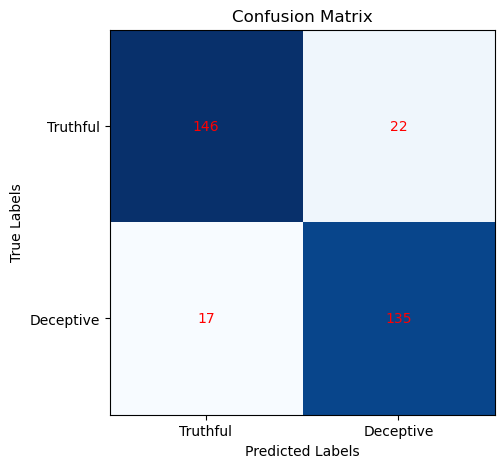

In [24]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 5))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks([0, 1], ['Truthful', 'Deceptive'])
plt.yticks([0, 1], ['Truthful', 'Deceptive'])
for i in range(len(cm)):
    for j in range(len(cm[i])):
        plt.text(j, i, cm[i][j], ha='center', va='center', color='red')
plt.show()